In [172]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df1 = pd.read_csv('C:/repos/ICD/IntroCD/dataset/raw/regular_season_box_scores_2010_2024_part_1.csv')
df2 = pd.read_csv('C:/repos/ICD/IntroCD/dataset/raw/regular_season_box_scores_2010_2024_part_2.csv')
df3 = pd.read_csv('C:/repos/ICD/IntroCD/dataset/raw/regular_season_box_scores_2010_2024_part_3.csv')
df4 = pd.read_csv('C:/repos/ICD/IntroCD/dataset/raw/regular_season_totals_2010_2024.csv')

df = pd.concat([df1, df2, df3], axis = 0)

df = df.drop(columns = ['jerseyNum', 'comment'], axis = 1)
df['position'] = df.groupby('personName')['position'].transform(lambda x: x.ffill().bfill())
df = df.dropna()
df['minutes'] = df['minutes'].astype(str)
df['minutes'] = df['minutes'].apply(lambda x: int(x.split(':')[0]) + (int(x.split(':')[1])/60))
selection = df4[['GAME_ID', 'WL', 'TEAM_ABBREVIATION']].copy()
selection = selection.rename({'GAME_ID' : 'gameId', 'TEAM_ABBREVIATION' : 'teamTricode'}, axis = 1)
df = pd.merge(df, selection, on = ['gameId', 'teamTricode'])
df.columns

Index(['season_year', 'game_date', 'gameId', 'matchup', 'teamId', 'teamCity',
       'teamName', 'teamTricode', 'teamSlug', 'personId', 'personName',
       'position', 'minutes', 'fieldGoalsMade', 'fieldGoalsAttempted',
       'fieldGoalsPercentage', 'threePointersMade', 'threePointersAttempted',
       'threePointersPercentage', 'freeThrowsMade', 'freeThrowsAttempted',
       'freeThrowsPercentage', 'reboundsOffensive', 'reboundsDefensive',
       'reboundsTotal', 'assists', 'steals', 'blocks', 'turnovers',
       'foulsPersonal', 'points', 'plusMinusPoints', 'WL'],
      dtype='object')

In [173]:
c_features = ['freeThrowsMade', 'reboundsDefensive', 'reboundsOffensive', 'blocks', 'plusMinusPoints']

g_features = ['threePointersAttempted', 'assists', 'steals', 'turnovers', 'plusMinusPoints']

f_features = ['threePointersAttempted', 'reboundsDefensive', 'steals', 'plusMinusPoints']

In [174]:
# Dummificando WL
df['W'] = df['WL'].map({'W': 1, 'L': 0})
df = df.drop(columns = ['WL'])

game_wins = df[['gameId', 'teamId', 'W']]
game_wins = game_wins.drop_duplicates(keep='first')

In [175]:
df_c = df[df['position'].str.count('C') > 0]

df_c['individual_position_score'] = df_c[c_features].mean(axis=1)

df_c = df_c[['gameId', 'teamId', 'individual_position_score', 'W']]

df_c

C:\Users\Raposo\AppData\Local\Temp\ipykernel_15572\1769475198.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_c['individual_position_score'] = df_c[c_features].mean(axis=1)


,gameId,teamId,individual_position_score,W
7,21000112,1610612751,1.6,1
15,21000020,1610612751,-1.4,1
18,21000020,1610612751,7.0,1
29,21000040,1610612751,-0.2,0
37,21000005,1610612751,0.8,1
...,...,...,...,...
342393,22301152,1610612764,2.2,0
342407,22301117,1610612764,3.2,0
342416,22301137,1610612764,3.8,0
342425,22301172,1610612764,3.8,0


In [176]:
df_g = df[df['position'].str.count('G') > 0]

df_g['individual_position_score'] = df_g[g_features].mean(axis=1)

df_g = df_g[['gameId', 'teamId', 'individual_position_score', 'W']]

df_g

C:\Users\Raposo\AppData\Local\Temp\ipykernel_15572\109851674.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_g['individual_position_score'] = df_g[g_features].mean(axis=1)


,gameId,teamId,individual_position_score,W
3,21000112,1610612751,4.0,1
6,21000112,1610612751,5.0,1
8,21000112,1610612751,5.2,1
13,21000020,1610612751,7.2,1
16,21000020,1610612751,-0.2,1
...,...,...,...,...
342418,22301172,1610612764,0.2,0
342421,22301172,1610612764,4.4,0
342426,22301186,1610612764,-1.2,0
342427,22301186,1610612764,5.6,0


In [177]:
df_f = df[df['position'].str.count('F') > 0]

df_f['individual_position_score'] = df_f[f_features].mean(axis=1)

df_f = df_f[['gameId', 'teamId', 'individual_position_score', 'W']]

df_f

C:\Users\Raposo\AppData\Local\Temp\ipykernel_15572\2124468642.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_f['individual_position_score'] = df_f[f_features].mean(axis=1)


,gameId,teamId,individual_position_score,W
0,21000112,1610612751,-1.00,1
1,21000112,1610612751,1.00,1
2,21000112,1610612751,-1.75,1
4,21000112,1610612751,5.50,1
5,21000112,1610612751,1.00,1
...,...,...,...,...
342424,22301172,1610612764,6.00,0
342429,22301186,1610612764,2.25,0
342431,22301186,1610612764,3.50,0
342432,22301186,1610612764,-3.00,0


In [178]:
df_c = df_c.groupby(['gameId', 'teamId'])['individual_position_score'].sum().reset_index()
df_c.rename(columns={'individual_position_score': 'c_score'}, inplace=True)

df_f = df_f.groupby(['gameId', 'teamId'])['individual_position_score'].sum().reset_index()
df_f.rename(columns={'individual_position_score': 'f_score'}, inplace=True)

df_g = df_g.groupby(['gameId', 'teamId'])['individual_position_score'].sum().reset_index()
df_g.rename(columns={'individual_position_score': 'g_score'}, inplace=True)

df_scores = pd.merge(df_c, df_f, on=['gameId', 'teamId'], how='inner')
df_scores = pd.merge(df_scores, df_g, on=['gameId', 'teamId'], how='inner')
df_scores = pd.merge(df_scores, game_wins, on=['gameId', 'teamId'], how='inner')

from sklearn import preprocessing

min_max_scaler = preprocessing.MinMaxScaler()
scaled = min_max_scaler.fit_transform(df_scores[['c_score', 'f_score', 'g_score']].values)

df_scores[['c_score', 'f_score', 'g_score']] = scaled

df_scores

,gameId,teamId,c_score,f_score,g_score,W
0,21000001,1610612738,0.492462,0.544928,0.501529,1
1,21000001,1610612748,0.462312,0.402899,0.388379,0
2,21000002,1610612756,0.356784,0.336232,0.397554,0
3,21000002,1610612757,0.457286,0.515942,0.620795,1
4,21000003,1610612745,0.477387,0.478261,0.452599,0
...,...,...,...,...,...,...
33311,22301228,1610612758,0.542714,0.507246,0.522936,1
33312,22301229,1610612749,0.417085,0.379710,0.437309,0
33313,22301229,1610612754,0.547739,0.428986,0.648318,1
33314,22301230,1610612740,0.281407,0.127536,0.223242,0


In [179]:
# Regressão logistica

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

X = df_scores[['c_score', 'f_score', 'g_score']]
y = df_scores['W']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[3183  117]
 [ 130 3234]]
              precision    recall  f1-score   support

           0       0.96      0.96      0.96      3300
           1       0.97      0.96      0.96      3364

    accuracy                           0.96      6664
   macro avg       0.96      0.96      0.96      6664
weighted avg       0.96      0.96      0.96      6664



In [180]:
import pandas as pd

# Pegue os coeficientes do modelo
coef = model.coef_[0]

# Relacione com os nomes das variáveis
features = ['c_score', 'f_score', 'g_score']
coef_df = pd.DataFrame({'feature': features, 'coeficiente': coef})
coef_df['influencia'] = coef_df['coeficiente'].abs()
coef_df = coef_df.sort_values('influencia', ascending=False)

print(coef_df)

   feature  coeficiente  influencia
1  f_score    29.969145   29.969145
2  g_score    26.969426   26.969426
0  c_score    16.736895   16.736895


C:\Users\Raposo\AppData\Local\Temp\ipykernel_15572\3896065753.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=coef_df, x='coeficiente', y='feature', palette='coolwarm')


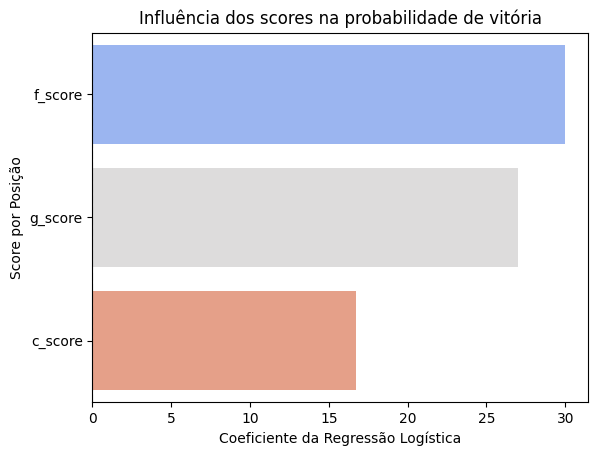

In [181]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.barplot(data=coef_df, x='coeficiente', y='feature', palette='coolwarm')
plt.axvline(0, color='gray', linestyle='--')
plt.title('Influência dos scores na probabilidade de vitória')
plt.xlabel('Coeficiente da Regressão Logística')
plt.ylabel('Score por Posição')
plt.show()

In [182]:
df_scores['W'].value_counts()

W
1    16658
0    16658
Name: count, dtype: int64